# Food & Beverage Market Analysis and Price Forecasting

### Time-Series Analysis of Commodity Prices, Consumer Indicators, and Financial Data

This notebook examines historical movements in selected food and beverage-related prices, applies **ARIMA time-series models** for forecasting, and supplements the analysis with consumer indicators and SMC financial report data.

**Tools:** Python, pandas, NumPy, Matplotlib, Seaborn, statsmodels, scikit-learn

> **Portfolio note:** The original source CSV files used for this analysis are not included in this portfolio copy. The outputs shown below are preserved from the notebook's original execution and have **not been regenerated or altered** during portfolio cleanup.


## Analysis Workflow

1. Load and combine historical commodity price data.
2. Standardize dates, select relevant variables, and handle missing observations.
3. Explore long-term and year-specific price trends.
4. Difference the time series and assess stationarity using autocorrelation plots and the Augmented Dickey-Fuller (ADF) test.
5. Compare ARIMA configurations using holdout RMSE and retain the best-performing specification for each series.
6. Generate short- and medium-horizon forecasts.
7. Review consumer indicators and financial report data as additional market context.


## 0. Environment Setup

Import the Python libraries used for data preparation, visualization, statistical testing, and ARIMA modeling.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.metrics import mean_squared_error
from math import sqrt

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

## 1. Commodity Price Data

The primary time-series dataset combines monthly livestock and coffee price observations into a single analytical table.


### 1.1 Data Loading and Preprocessing

The source files are loaded, merged by year and month, converted to a monthly date index, and reduced to the variables used in the analysis. Missing observations are handled using interpolation followed by forward/backward filling.


In [ ]:
livestock = pd.read_csv('livestock.csv')
livestock.head()

,Year,Month,Carabao for Slaughter,Cattle for Slaughter,Hogs Upgraded for Slaughter,"Chicken Broiler, other breed","Chicken egg, other breed"
0,2013,January,NaN,NaN,NaN,83.66,4.45
1,2013,February,NaN,NaN,NaN,81.15,4.45
2,2013,March,NaN,NaN,NaN,83.66,4.40
3,2013,April,NaN,NaN,NaN,80.04,4.37
4,2013,May,NaN,NaN,NaN,81.31,4.37


In [ ]:
coffee = pd.read_csv('coffee.csv')
coffee.head()

,Year,Month,Coffee Arabica (roasted),Coffee Robusta (roasted)
0,2013,January,350.0,210.0
1,2013,February,350.0,210.0
2,2013,March,350.0,210.0
3,2013,April,350.0,210.0
4,2013,May,350.0,210.0


In [ ]:
df1 = pd.merge(livestock, coffee, on=['Year', 'Month'])
df1

,Year,Month,Carabao for Slaughter,Cattle for Slaughter,Hogs Upgraded for Slaughter,"Chicken Broiler, other breed","Chicken egg, other breed",Coffee Arabica (roasted),Coffee Robusta (roasted)
0,2013,January,NaN,NaN,NaN,83.660000,4.450000,350.00,210.00
1,2013,February,NaN,NaN,NaN,81.150000,4.450000,350.00,210.00
2,2013,March,NaN,NaN,NaN,83.660000,4.400000,350.00,210.00
3,2013,April,NaN,NaN,NaN,80.040000,4.370000,350.00,210.00
4,2013,May,NaN,NaN,NaN,81.310000,4.370000,350.00,210.00
...,...,...,...,...,...,...,...,...,...
127,2023,August,131.688750,184.546898,164.433772,120.954144,6.664954,677.78,365.93
128,2023,September,141.665414,180.651543,164.901152,120.721334,6.842733,686.67,373.33
129,2023,October,139.070000,184.718192,162.765045,111.800258,7.214502,686.67,373.33
130,2023,November,142.450000,189.268395,161.045445,116.064857,7.299351,686.67,371.85


In [ ]:
month_mapping = {month: index for index, month in enumerate(
    ['January', 'February', 'March', 'April', 'May', 'June', 
     'July', 'August', 'September', 'October', 'November', 'December'], start=1)}


df1['Month'] = df1['Month'].map(month_mapping)

df1['Date'] = pd.to_datetime(df1[['Year', 'Month']].assign(DAY=1))

df1 = df1[['Date', 'Cattle for Slaughter', 'Hogs Upgraded for Slaughter', 
            'Chicken Broiler, other breed',  'Coffee Arabica (roasted)']]

df1

,Date,Cattle for Slaughter,Hogs Upgraded for Slaughter,"Chicken Broiler, other breed",Coffee Arabica (roasted)
0,2013-01-01,NaN,NaN,83.660000,350.00
1,2013-02-01,NaN,NaN,81.150000,350.00
2,2013-03-01,NaN,NaN,83.660000,350.00
3,2013-04-01,NaN,NaN,80.040000,350.00
4,2013-05-01,NaN,NaN,81.310000,350.00
...,...,...,...,...,...
127,2023-08-01,184.546898,164.433772,120.954144,677.78
128,2023-09-01,180.651543,164.901152,120.721334,686.67
129,2023-10-01,184.718192,162.765045,111.800258,686.67
130,2023-11-01,189.268395,161.045445,116.064857,686.67


In [ ]:
col_names = {'Cattle for Slaughter': 'Cattle', 'Hogs Upgraded for Slaughter': 'Hogs', 
             'Chicken Broiler, other breed':'Chicken', 'Coffee Arabica (roasted)': 'Coffee Arabica'}

df1 = df1.rename(columns=col_names)

df1

,Date,Cattle,Hogs,Chicken,Coffee Arabica
0,2013-01-01,NaN,NaN,83.660000,350.00
1,2013-02-01,NaN,NaN,81.150000,350.00
2,2013-03-01,NaN,NaN,83.660000,350.00
3,2013-04-01,NaN,NaN,80.040000,350.00
4,2013-05-01,NaN,NaN,81.310000,350.00
...,...,...,...,...,...
127,2023-08-01,184.546898,164.433772,120.954144,677.78
128,2023-09-01,180.651543,164.901152,120.721334,686.67
129,2023-10-01,184.718192,162.765045,111.800258,686.67
130,2023-11-01,189.268395,161.045445,116.064857,686.67


In [ ]:
df1 = df1.interpolate()
df1 = df1.ffill().bfill()
df1

,Date,Cattle,Hogs,Chicken,Coffee Arabica
0,2013-01-01,95.230000,106.220000,83.660000,350.00
1,2013-02-01,95.230000,106.220000,81.150000,350.00
2,2013-03-01,95.230000,106.220000,83.660000,350.00
3,2013-04-01,95.230000,106.220000,80.040000,350.00
4,2013-05-01,95.230000,106.220000,81.310000,350.00
...,...,...,...,...,...
127,2023-08-01,184.546898,164.433772,120.954144,677.78
128,2023-09-01,180.651543,164.901152,120.721334,686.67
129,2023-10-01,184.718192,162.765045,111.800258,686.67
130,2023-11-01,189.268395,161.045445,116.064857,686.67


### 1.2 Exploratory Trend Analysis

Historical trends are visualized across the full observation period, with additional views for 2022 and 2023 and yearly distribution comparisons.


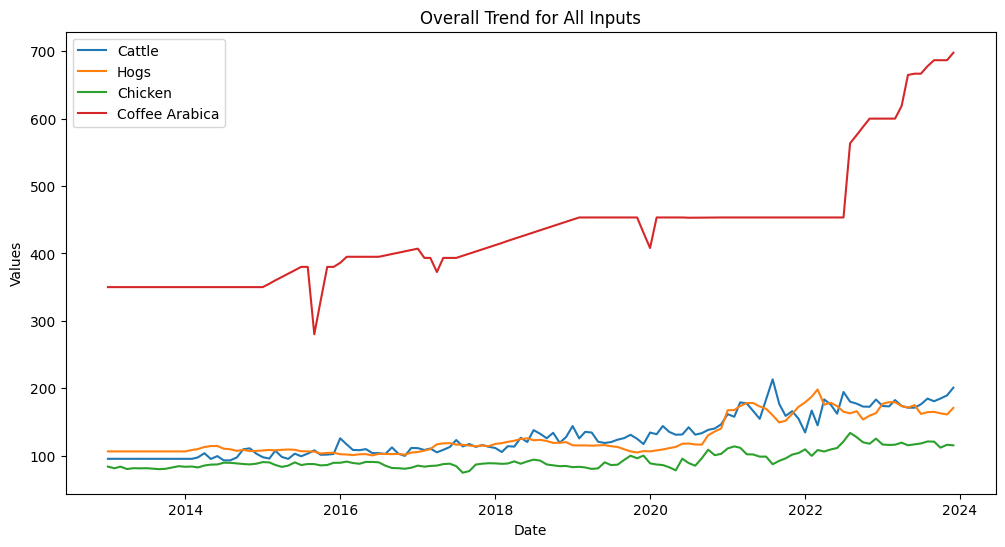

In [ ]:
columns_to_plot = [col for col in df1.columns if col != 'Date']  # all columns except date

plt.figure(figsize=(12, 6))

for column in columns_to_plot:
    plt.plot(df1['Date'], df1[column], label=column)

plt.title('Overall Trend for All Inputs')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.show()

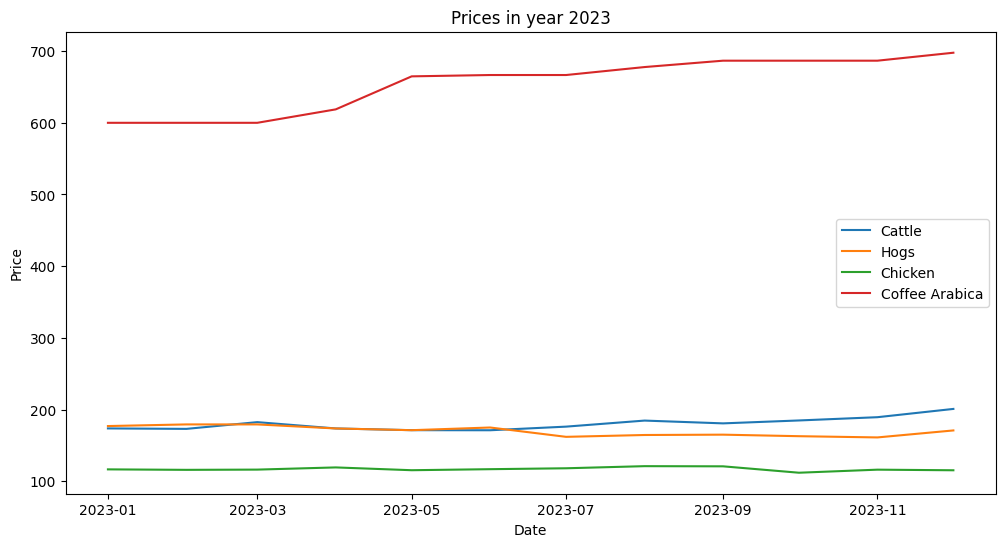

In [ ]:
df_2023 = df1[df1['Date'].dt.year == 2023]

df_2023

plt.figure(figsize=(12, 6))

for column in columns_to_plot:
    plt.plot(df_2023['Date'], df_2023[column], label=column)

plt.title('Prices in year 2023')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

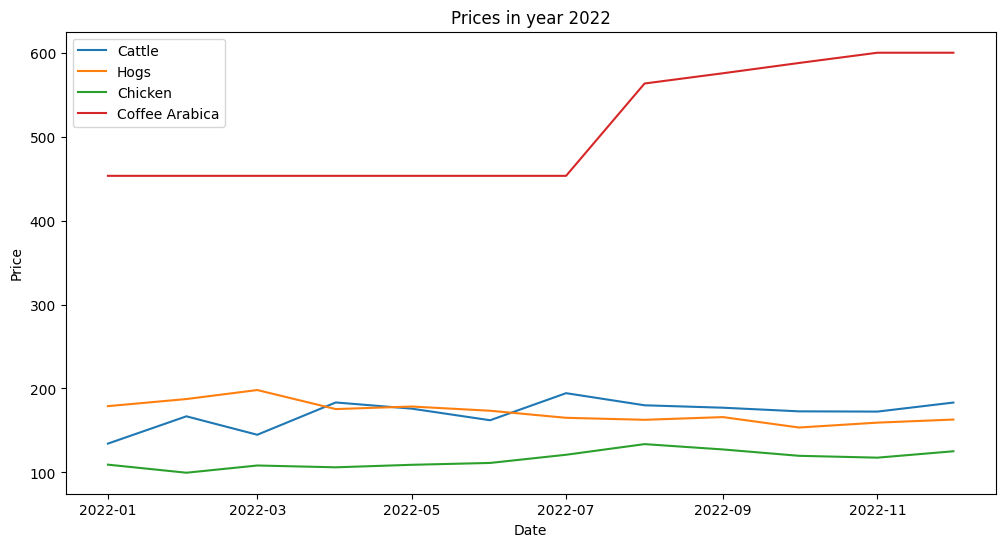

In [ ]:
df_2022 = df1[df1['Date'].dt.year == 2022]

df_2022

plt.figure(figsize=(12, 6))

for column in columns_to_plot:
    plt.plot(df_2022['Date'], df_2022[column], label=column)

plt.title('Prices in year 2022')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

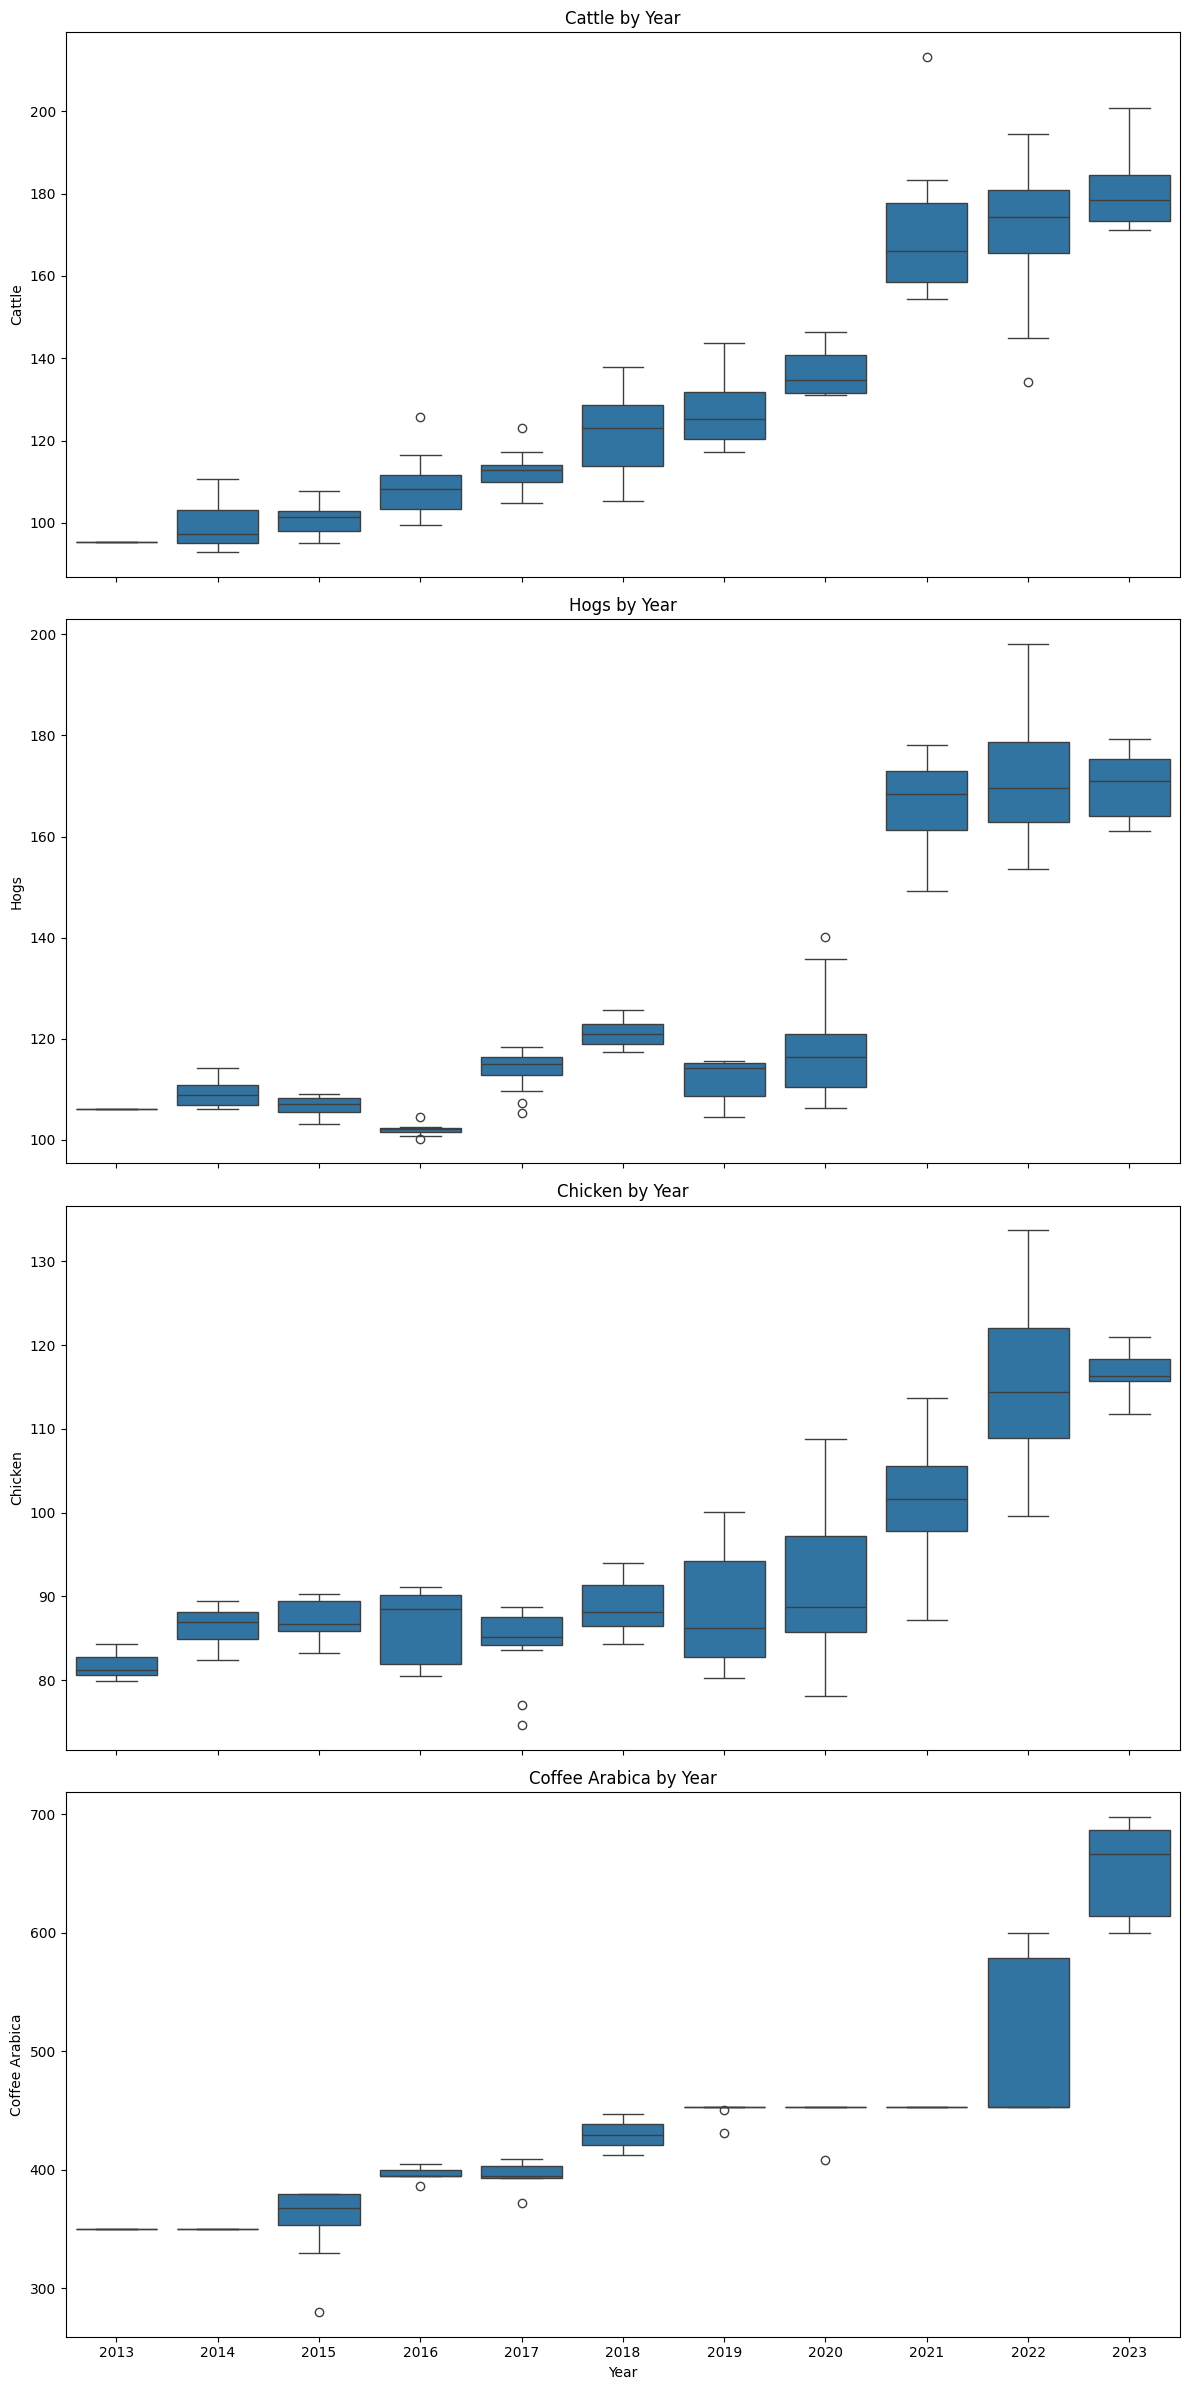

In [ ]:
df1['Year'] = df1['Date'].dt.year

y_columns = [col for col in df1.columns if col not in ['Date', 'Year']]

num_plots = len(y_columns)
fig, axes = plt.subplots(num_plots, 1, figsize=(12, 6 * num_plots), sharex=True)

if num_plots == 1:
    axes = [axes] 

for ax, y_col in zip(axes, y_columns):
    sns.boxplot(x='Year', y=y_col, data=df1, ax=ax)
    ax.set_title(f'{y_col} by Year')
    ax.set_xlabel('Year')
    ax.set_ylabel(y_col)

plt.tight_layout()
plt.show()


## 2. Time-Series Forecasting

ARIMA models are used to evaluate and forecast four price series: cattle, hogs, chicken, and Arabica coffee.


### 2.1 Differencing for Stationarity

First-order differencing is applied to inspect how changes between consecutive observations affect the underlying time-series behavior.


In [ ]:
def difference(df, column, interval=1):
    X = df[column]
    diff = [X[i] - X[i - interval] for i in range(interval, len(X))]
    return pd.Series(diff, name=f'{column}_diff')

In [ ]:
def difference_plot(df, column, interval=1):
    # Calculate the differenced data
    X = df[column]
    X_difference = difference(df, column, interval)
    
    # Plot
    plt.figure(figsize=(12, 4))
    plt.plot(df.index[interval:], X[interval:], label='Original Data', color='blue')
    plt.plot(df.index[interval:], X_difference, label='Differenced Data', color='red')
    
    plt.title(f'Original Data and Differenced Data for {column}')
    plt.xlabel('Time')
    plt.ylabel(column)
    plt.legend()
    
    plt.show()

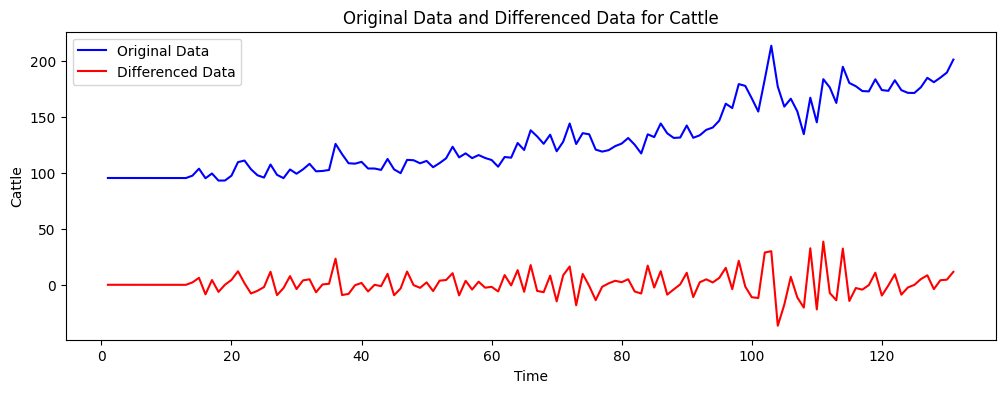

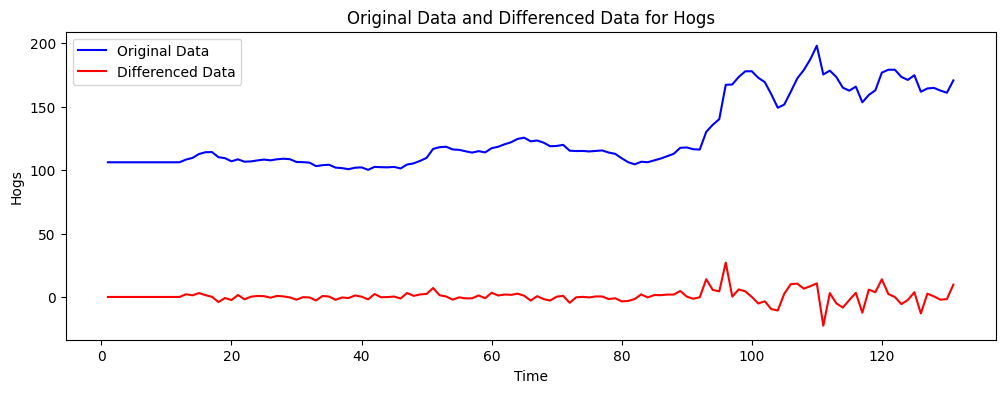

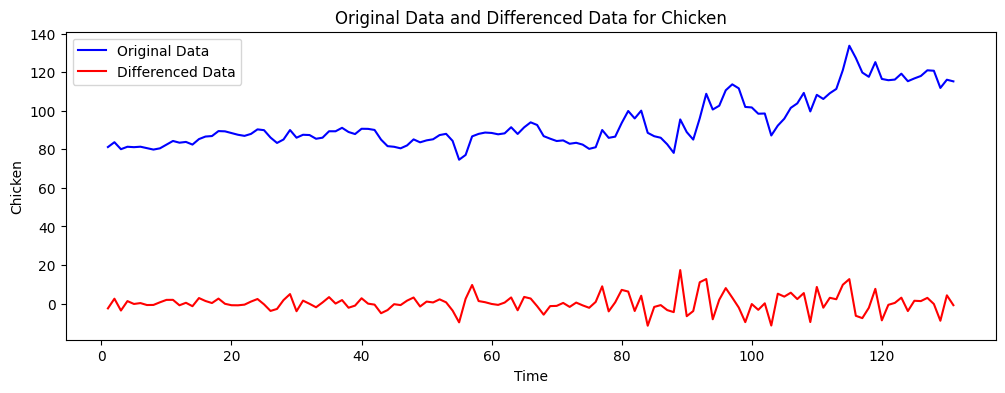

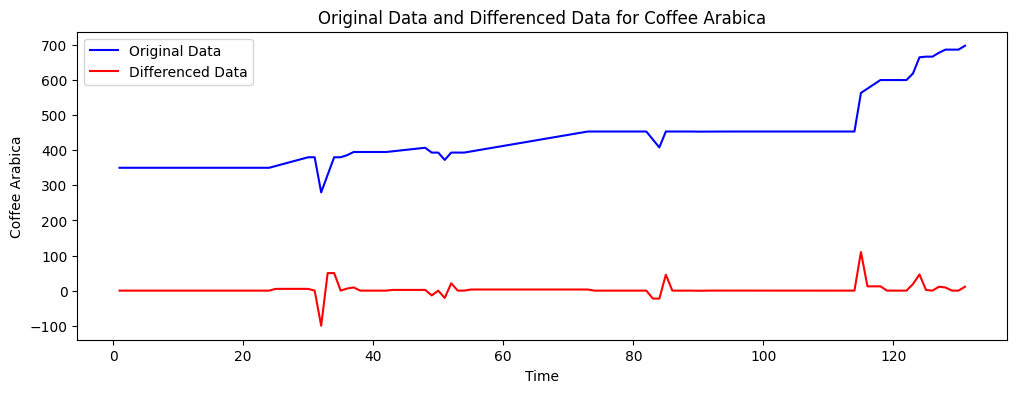

In [ ]:
exclude_columns = ['Date', 'Year']

# iterate through columns instead of exclude_columns
for column in df1.columns:
    if column not in exclude_columns:
        difference_plot(df1, column, interval=1)

### 2.2 Stationarity Diagnostics: ACF and ADF Test

Autocorrelation plots and the Augmented Dickey-Fuller (ADF) test are used to assess whether each differenced series is stationary. At the 5% significance level, the original run rejects the unit-root null hypothesis for all four differenced series.


#### Cattle

<Figure size 1200x800 with 0 Axes>

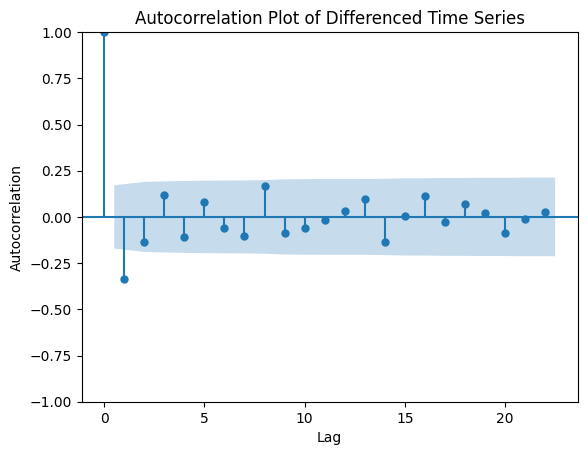

In [ ]:
cattle_diff = difference(df1, 'Cattle', interval= 1)
cattle_diff_df = pd.DataFrame(cattle_diff)

plt.figure(figsize=(12, 8))
plot_acf(cattle_diff_df)  
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Plot of Differenced Time Series')
plt.show()

In [ ]:
result = adfuller(cattle_diff)

adf_statistic = result[0]
p_value = result[1]
critical_values = result[4]

print('Augmented Dickey-Fuller Test:')
print(f'ADF Statistic: {adf_statistic}')
print(f'p-value: {p_value}')
print('Critical Values:')
for key, value in critical_values.items():
    print(f'   {key}: {value}')

if p_value < 0.05:
    print("Reject the null hypothesis: The series is stationary.")
else:
    print("Fail to reject the null hypothesis: The series is non-stationary.")

Augmented Dickey-Fuller Test:
ADF Statistic: -12.231491828516392
p-value: 1.0511096385769722e-22
Critical Values:
   1%: -3.482087964046026
   5%: -2.8842185101614626
   10%: -2.578864381347275
Reject the null hypothesis: The series is stationary.


#### Hogs

<Figure size 1200x800 with 0 Axes>

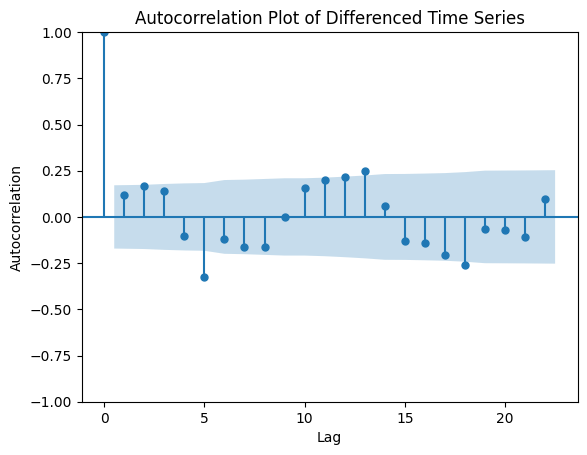

In [ ]:
hogs_diff = difference(df1, 'Hogs', interval=1)

hogs_diff_df = pd.DataFrame(hogs_diff)

plt.figure(figsize=(12, 8))
plot_acf(hogs_diff_df)  
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Plot of Differenced Time Series')
plt.show()

In [ ]:
result = adfuller(hogs_diff)

adf_statistic = result[0]
p_value = result[1]
critical_values = result[4]

print('Augmented Dickey-Fuller Test:')
print(f'ADF Statistic: {adf_statistic}')
print(f'p-value: {p_value}')
print('Critical Values:')
for key, value in critical_values.items():
    print(f'   {key}: {value}')

if p_value < 0.05:
    print("Reject the null hypothesis: The series is stationary.")
else:
    print("Fail to reject the null hypothesis: The series is non-stationary.")

Augmented Dickey-Fuller Test:
ADF Statistic: -6.976384887679641
p-value: 8.407739183625281e-10
Critical Values:
   1%: -3.4833462346078936
   5%: -2.8847655969877666
   10%: -2.5791564575459813
Reject the null hypothesis: The series is stationary.


#### Chicken

<Figure size 1200x800 with 0 Axes>

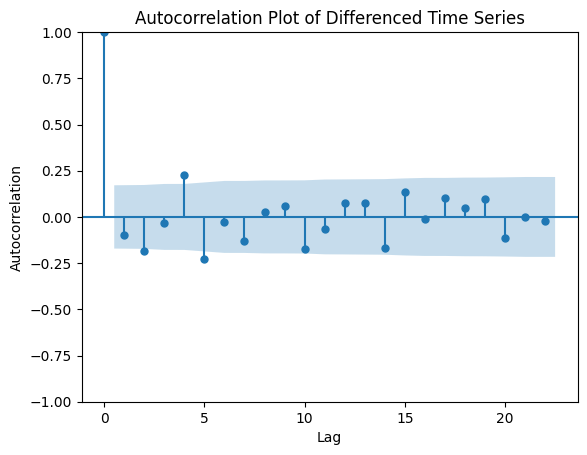

In [ ]:
chicken_diff = difference(df1, 'Chicken', interval=1)

chicken_diff_df = pd.DataFrame(chicken_diff)

plt.figure(figsize=(12, 8))
plot_acf(chicken_diff_df)  
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Plot of Differenced Time Series')
plt.show()

In [ ]:
result = adfuller(chicken_diff)

adf_statistic = result[0]
p_value = result[1]
critical_values = result[4]

print('Augmented Dickey-Fuller Test:')
print(f'ADF Statistic: {adf_statistic}')
print(f'p-value: {p_value}')
print('Critical Values:')
for key, value in critical_values.items():
    print(f'   {key}: {value}')

if p_value < 0.05:
    print("Reject the null hypothesis: The series is stationary.")
else:
    print("Fail to reject the null hypothesis: The series is non-stationary.")

Augmented Dickey-Fuller Test:
ADF Statistic: -5.567446166868879
p-value: 1.4935851284230813e-06
Critical Values:
   1%: -3.485585145896754
   5%: -2.885738566292665
   10%: -2.5796759080663887
Reject the null hypothesis: The series is stationary.


#### Arabica Coffee

<Figure size 1200x800 with 0 Axes>

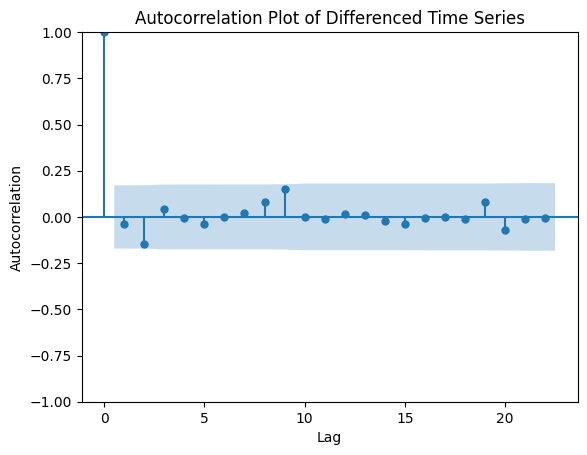

In [ ]:
coffee_diff = difference(df1, 'Coffee Arabica', interval=1)

coffee_diff_df = pd.DataFrame(coffee_diff)

plt.figure(figsize=(12, 8))
plot_acf(coffee_diff_df)  
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Plot of Differenced Time Series')
plt.show()

In [ ]:
result = adfuller(coffee_diff)

adf_statistic = result[0]
p_value = result[1]
critical_values = result[4]

print('Augmented Dickey-Fuller Test:')
print(f'ADF Statistic: {adf_statistic}')
print(f'p-value: {p_value}')
print('Critical Values:')
for key, value in critical_values.items():
    print(f'   {key}: {value}')

if p_value < 0.05:
    print("Reject the null hypothesis: The series is stationary.")
else:
    print("Fail to reject the null hypothesis: The series is non-stationary.")

Augmented Dickey-Fuller Test:
ADF Statistic: -9.40376909816412
p-value: 6.088438464269519e-16
Critical Values:
   1%: -3.482087964046026
   5%: -2.8842185101614626
   10%: -2.578864381347275
Reject the null hypothesis: The series is stationary.


### 2.3 ARIMA Model Selection

Candidate ARIMA configurations are evaluated using a grid search over `(p, d, q)` values. Model performance is compared using **root mean squared error (RMSE)** on the held-out test observations.


In [ ]:
train, test = df1[0:len(df1)-24], df1[-24:]

def arima_model(train_data, test_data, p, d, q):
    try:
        model = ARIMA(train_data, order=(p, d, q))
        model_fit = model.fit()
        forecast = model_fit.forecast(steps=len(test_data))
        rmse = sqrt(mean_squared_error(test_data, forecast))
        return model_fit, rmse
    except Exception as e:
        print(f"ARIMA({p},{d},{q}) failed with error: {e}")
        return None, float('inf')

p_values = range(0, 6)
d_values = range(0, 2)
q_values = range(0, 6)

#### Cattle

In [ ]:
cattle_train = train.loc[:, 'Cattle']
cattle_test = test.loc[:, 'Cattle']

cattle_best_rmse = float('inf')
cattle_best_order = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                cattle_model_fit, cattle_rmse = arima_model(cattle_train, cattle_test, p, d, q)
                if cattle_rmse < cattle_best_rmse:
                    cattle_best_rmse = cattle_rmse
                    cattle_best_order = (p, d, q)
                # print(f"ARIMA({p},{d},{q})  RMSE = {cattle_rmse:.3f}")

print(f"\nBest ARIMA model for Cattle: ARIMA{cattle_best_order} with RMSE = {cattle_best_rmse:.3f}")


Best ARIMA model for Cattle: ARIMA(2, 1, 5) with RMSE = 12.907


#### Hogs

In [ ]:
hogs_train = train.loc[:, 'Hogs']
hogs_test = test.loc[:, 'Hogs']

hogs_best_rmse = float('inf')
hogs_best_order = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                hogs_model_fit, hogs_rmse = arima_model(hogs_train, hogs_test, p, d, q)
                if hogs_rmse < hogs_best_rmse:
                    hogs_best_rmse = hogs_rmse
                    hogs_best_order = (p, d, q)
                # print(f"ARIMA({p},{d},{q})  RMSE = {hogs_rmse:.3f}")

print(f"\nBest ARIMA model for Hogs: ARIMA{hogs_best_order} with RMSE = {hogs_best_rmse:.3f}")


Best ARIMA model for Hogs: ARIMA(3, 0, 4) with RMSE = 8.726


#### Chicken

In [ ]:
chicken_train = train.loc[:, 'Chicken']
chicken_test = test.loc[:, 'Chicken']

chicken_best_rmse = float('inf')
chicken_best_order = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                chicken_model_fit, chicken_rmse = arima_model(chicken_train, chicken_test, p, d, q)
                if chicken_rmse < chicken_best_rmse:
                    chicken_best_rmse = chicken_rmse
                    chicken_best_order = (p, d, q)
                # print(f"ARIMA({p},{d},{q})  RMSE = {chicken_rmse:.3f}")

print(f"\nBest ARIMA model for Chicken: ARIMA{chicken_best_order} with RMSE = {chicken_best_rmse:.3f}")


Best ARIMA model for Chicken: ARIMA(0, 1, 4) with RMSE = 6.908


#### Arabica Coffee

In [ ]:
coffee_train, coffee_test = df1[0:len(df1)-6], df1[-6:]

coffee_train = coffee_train.loc[:, 'Coffee Arabica']
coffee_test = coffee_test.loc[:, 'Coffee Arabica']

coffee_best_rmse = float('inf')
coffee_best_order = None

for p in p_values:
    for d in d_values:
        for q in q_values:
            with warnings.catch_warnings():
                warnings.filterwarnings("ignore")
                coffee_model_fit, coffee_rmse = arima_model(coffee_train, coffee_test, p, d, q)
                if coffee_rmse < coffee_best_rmse:
                    coffee_best_rmse = coffee_rmse
                    coffee_best_order = (p, d, q)
                # print(f"ARIMA({p},{d},{q})  RMSE = {coffee_rmse:.3f}")

print(f"\nBest ARIMA model for Coffee: ARIMA{coffee_best_order} with RMSE = {coffee_best_rmse:.3f}")


Best ARIMA model for Coffee: ARIMA(2, 1, 3) with RMSE = 3.725


#### Selected Models from the Original Run

| Series | Selected ARIMA Order | Holdout RMSE |
|---|---:|---:|
| Cattle | ARIMA(2, 1, 5) | 12.907 |
| Hogs | ARIMA(3, 0, 4) | 8.726 |
| Chicken | ARIMA(0, 1, 4) | 6.908 |
| Arabica Coffee | ARIMA(2, 1, 3) | 3.725 |

These values are taken directly from the stored outputs of the original notebook execution.


### 2.4 Forecast Evaluation and Projections

The selected models are compared against held-out observations and then used to produce 4-, 6-, and 12-step forecasts.


In [ ]:
def plot_arima_predictions(model, train_data, test_data):
    """
    Plot the predicted time series data together with the original test data using an ARIMA model.
    
    Parameters:
        model (ARIMA): The fitted ARIMA model.
        train_data (pd.Series or np.array): Training data.
        test_data (pd.Series or np.array): Test data.
    """
    
    # Forecast the test data
    start = len(train_data)
    end = start + len(test_data) - 1
    predictions = model.predict(start=start, end=end, dynamic=False)
    
    # Create a combined series of training data and predicted data
    train_data_series = pd.Series(train_data, index=range(len(train_data)))
    predicted_series = pd.Series(predictions, index=range(start, end + 1))
    test_data_series = pd.Series(test_data, index=range(start, end + 1))
    
    # Plot the results
    plt.figure(figsize=(12, 6))
    plt.plot(train_data_series, label='Training Data')
    plt.plot(test_data_series, label='Test Data', color='orange')
    plt.plot(predicted_series, label='Predicted Data', color='green',ls='dashed')
    plt.title('ARIMA Model Predictions vs Actual Data')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()

#### Cattle

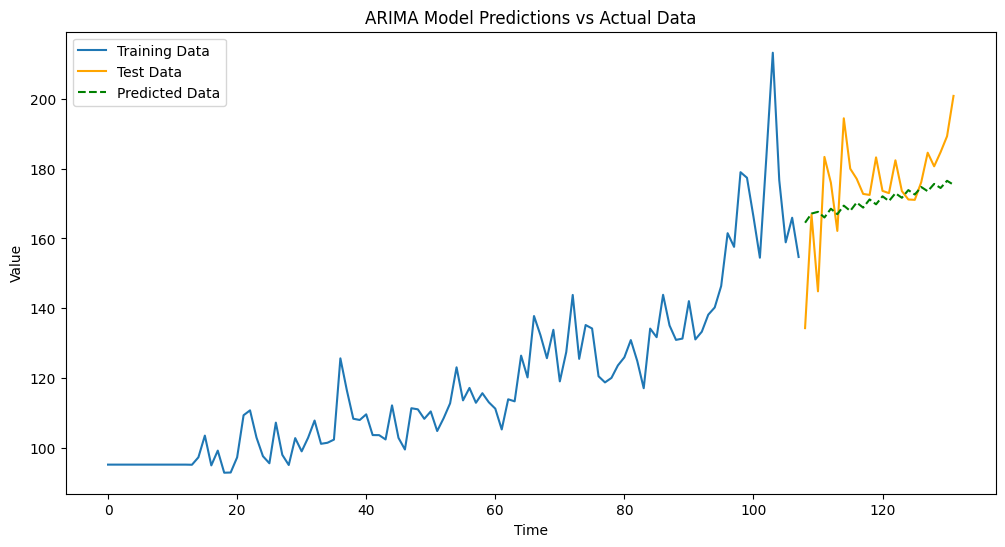

In [ ]:
cattle_model_fit, cattle_rmse = arima_model(cattle_train, cattle_test, cattle_best_order[0], cattle_best_order[1], cattle_best_order[2])

plot_arima_predictions(cattle_model_fit, cattle_train, cattle_test)

In [ ]:
# Quarter Forecast
cattle_forecast = cattle_model_fit.forecast(steps=4)
cattle_forecast

108    164.500748
109    167.122722
110    167.615880
111    165.998707
Name: predicted_mean, dtype: float64

In [ ]:
# Half Year Forecast
cattle_forecast = cattle_model_fit.forecast(steps=6)
cattle_forecast

108    164.500748
109    167.122722
110    167.615880
111    165.998707
112    168.504302
113    166.943213
Name: predicted_mean, dtype: float64

In [ ]:
# Year Forecast
cattle_forecast = cattle_model_fit.forecast(steps=12)
cattle_forecast

108    164.500748
109    167.122722
110    167.615880
111    165.998707
112    168.504302
113    166.943213
114    169.392796
115    167.886258
116    170.281343
117    168.827862
118    171.169921
119    169.768046
Name: predicted_mean, dtype: float64

#### Hogs

/root/venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


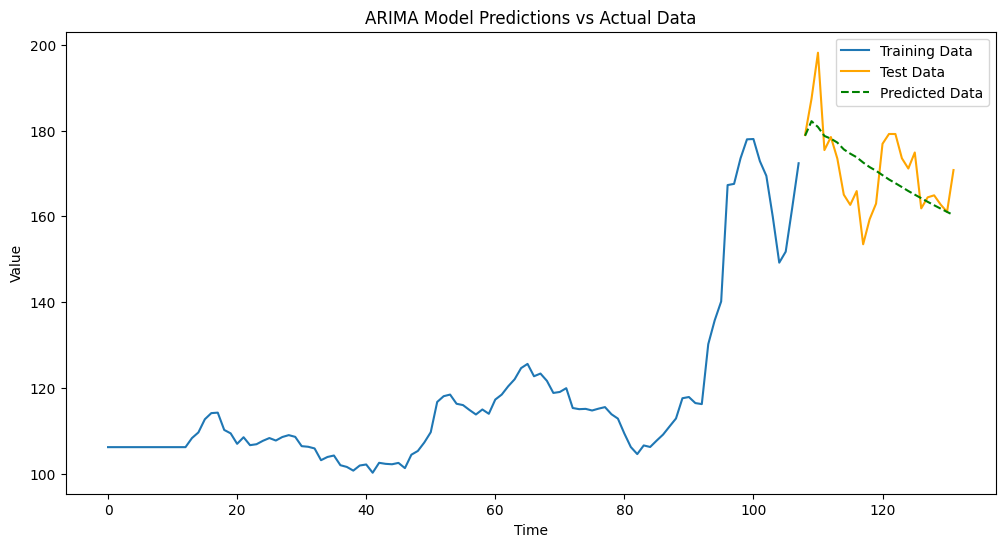

In [ ]:
hogs_model_fit, hogs_rmse = arima_model(hogs_train, hogs_test, hogs_best_order[0], hogs_best_order[1], hogs_best_order[2])

plot_arima_predictions(hogs_model_fit, hogs_train, hogs_test)

In [ ]:
# Quarter Forecast
hogs_forecast = hogs_model_fit.forecast(steps=4)
hogs_forecast

108    178.785388
109    182.175115
110    180.818722
111    178.734714
Name: predicted_mean, dtype: float64

In [ ]:
# Half Year Forecast
hogs_forecast = hogs_model_fit.forecast(steps=6)
hogs_forecast

108    178.785388
109    182.175115
110    180.818722
111    178.734714
112    178.100301
113    177.194162
Name: predicted_mean, dtype: float64

In [ ]:
# Year Forecast
hogs_forecast = hogs_model_fit.forecast(steps=12)
hogs_forecast

108    178.785388
109    182.175115
110    180.818722
111    178.734714
112    178.100301
113    177.194162
114    175.610655
115    174.612827
116    173.770573
117    172.544003
118    171.482321
119    170.619032
Name: predicted_mean, dtype: float64

#### Chicken

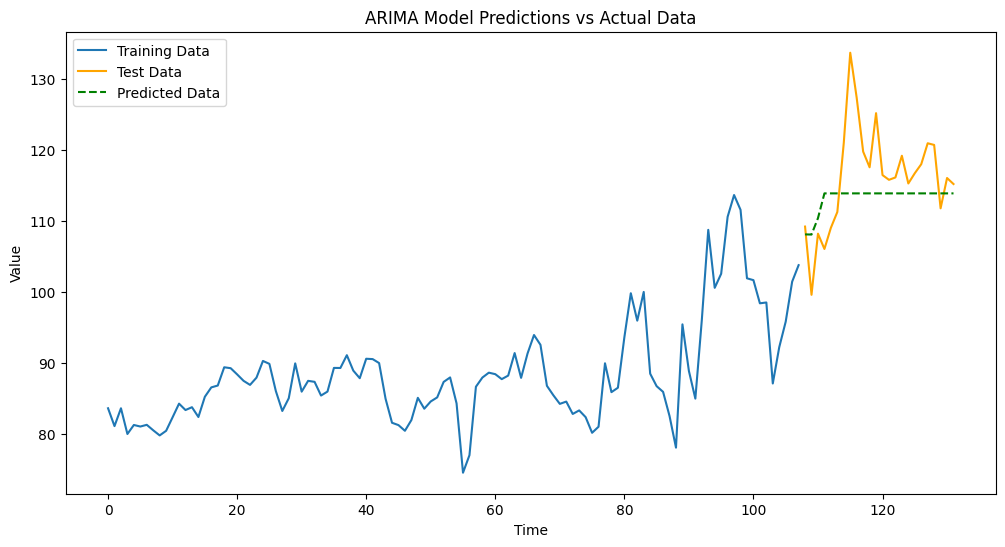

In [ ]:
chicken_model_fit, chicken_rmse = arima_model(chicken_train, chicken_test, chicken_best_order[0], chicken_best_order[1], chicken_best_order[2])

plot_arima_predictions(chicken_model_fit, chicken_train, chicken_test)

In [ ]:
# Quarter Forecast
chicken_forecast = chicken_model_fit.forecast(steps=4)
chicken_forecast

108    108.130647
109    108.108323
110    110.419292
111    113.902267
Name: predicted_mean, dtype: float64

In [ ]:
# Half Year Forecast
chicken_forecast = chicken_model_fit.forecast(steps=6)
chicken_forecast

108    108.130647
109    108.108323
110    110.419292
111    113.902267
112    113.902267
113    113.902267
Name: predicted_mean, dtype: float64

In [ ]:
# Year Forecast
chicken_forecast = chicken_model_fit.forecast(steps=12)
chicken_forecast

108    108.130647
109    108.108323
110    110.419292
111    113.902267
112    113.902267
113    113.902267
114    113.902267
115    113.902267
116    113.902267
117    113.902267
118    113.902267
119    113.902267
Name: predicted_mean, dtype: float64

#### Arabica Coffee

/root/venv/lib/python3.9/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


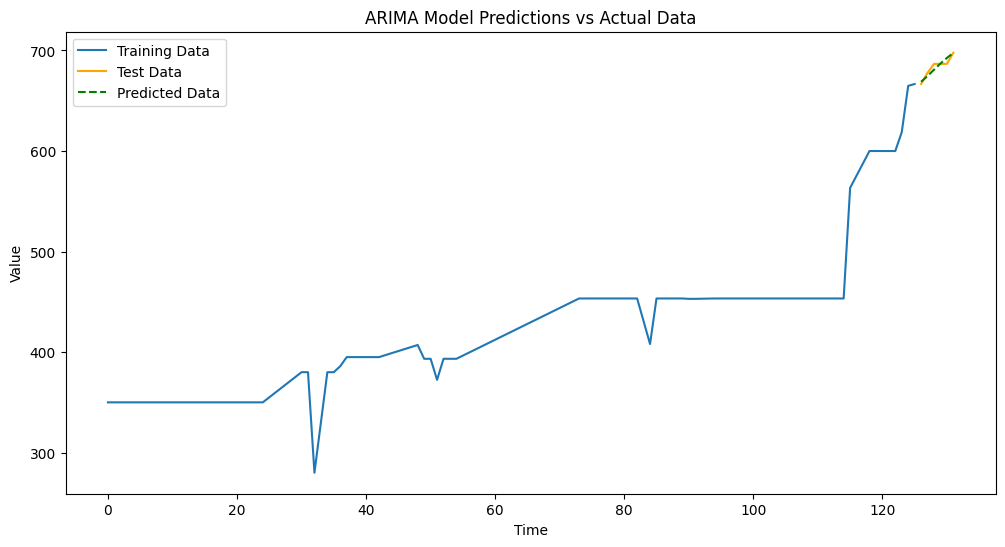

In [ ]:
coffee_model_fit, coffee_rmse = arima_model(coffee_train, coffee_test, coffee_best_order[0], coffee_best_order[1], coffee_best_order[2])

plot_arima_predictions(coffee_model_fit, coffee_train, coffee_test)

In [ ]:
# Quarter Forecast
coffee_forecast = coffee_model_fit.forecast(steps=4)
coffee_forecast

126    668.883507
127    674.647866
128    680.924015
129    687.020708
Name: predicted_mean, dtype: float64

In [ ]:
# Half Year Forecast
coffee_forecast = coffee_model_fit.forecast(steps=6)
coffee_forecast

126    668.883507
127    674.647866
128    680.924015
129    687.020708
130    692.617726
131    697.594968
Name: predicted_mean, dtype: float64

In [ ]:
# Year Forecast
coffee_forecast = coffee_model_fit.forecast(steps=12)
coffee_forecast

126    668.883507
127    674.647866
128    680.924015
129    687.020708
130    692.617726
131    697.594968
132    701.936710
133    705.678478
134    708.878037
135    711.599928
136    713.907574
137    715.859559
Name: predicted_mean, dtype: float64

## 3. Consumer and Macroeconomic Indicators

Consumer-side indicators are reviewed to provide broader context for the price analysis. The notebook includes the Consumer Price Index, food and beverage inflation, purchasing power of the peso, core inflation, and a quarterly expenditure-confidence index.


In [ ]:
df2 = pd.read_csv('Consumer Data.csv')
df2.head(12)

,Year,Month,Consumer Price Index (2018 =100),Food and Beverages Inflation,Purchasing Power of the Peso,Core Inflation
0,2013,Jan,82.1,2.7,1.16,3.2
1,2013,Feb,82.0,2.9,1.15,3.2
2,2013,Mar,81.9,2.7,1.15,3.2
3,2013,Apr,81.9,2.0,1.15,2.7
4,2013,May,82.0,2.2,1.15,2.7
5,2013,Jun,82.2,2.1,1.15,2.8
6,2013,Jul,82.5,1.9,1.14,2.4
7,2013,Aug,82.9,1.3,1.14,2.0
8,2013,Sep,83.8,2.2,1.14,2.3
9,2013,Oct,84.3,2.9,1.13,2.3


In [ ]:
month_mapping2 = {month: index for index, month in enumerate(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], start=1)}

df2['Month'] = df2['Month'].map(month_mapping2)

df2['Date'] = pd.to_datetime(df2[['Year', 'Month']].assign(DAY=1))

df2 = df2[['Date', 'Consumer Price Index (2018 =100)', 'Food and Beverages Inflation', 
          'Purchasing Power of the Peso', 'Core Inflation']]

df2

,Date,Consumer Price Index (2018 =100),Food and Beverages Inflation,Purchasing Power of the Peso,Core Inflation
0,2013-01-01,82.1,2.7,1.16,3.2
1,2013-02-01,82.0,2.9,1.15,3.2
2,2013-03-01,81.9,2.7,1.15,3.2
3,2013-04-01,81.9,2.0,1.15,2.7
4,2013-05-01,82.0,2.2,1.15,2.7
...,...,...,...,...,...
127,2023-08-01,125.5,8.1,0.82,6.1
128,2023-09-01,128.0,9.7,0.81,5.9
129,2023-10-01,126.7,7.0,0.81,5.3
130,2023-11-01,127.0,5.7,0.81,4.7


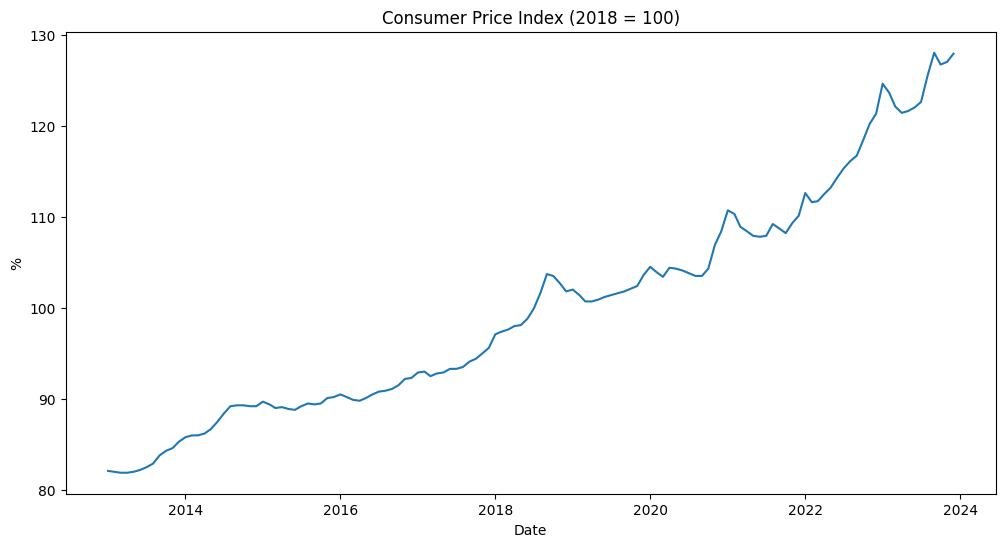

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df2['Date'], df2['Consumer Price Index (2018 =100)'])
plt.title('Consumer Price Index (2018 = 100)')
plt.ylabel('%')
plt.xlabel('Date')
plt.show()

In [ ]:
df3 = pd.read_csv('CIAE (Quarterly).csv')
df3.head(4)

,Year,Quarter,Confidence Index on Amount of Expenditures (PH)
0,2013,Q1,60.553
1,2013,Q2,59.259
2,2013,Q3,64.366
3,2013,Q4,62.398


In [ ]:
quarter_to_month = {
    'Q1': '01',  # January
    'Q2': '04',  # April
    'Q3': '07',  # July
    'Q4': '10'   # October
}

# Create a new column with datetime format
df3['Date'] = df3.apply(lambda row: pd.to_datetime(f"{row['Year']}-{quarter_to_month[row['Quarter']]}-01"), axis=1)

df3 = df3[['Date', 'Confidence Index on Amount of Expenditures (PH)']]

df3

,Date,Confidence Index on Amount of Expenditures (PH)
0,2013-01-01,60.553
1,2013-04-01,59.259
2,2013-07-01,64.366
3,2013-10-01,62.398
4,2014-01-01,64.584
5,2014-04-01,65.813
6,2014-07-01,67.512
7,2014-10-01,67.240
8,2015-01-01,49.296
9,2015-04-01,50.367


In [ ]:
df3 = df3.interpolate()
df3

,Date,Confidence Index on Amount of Expenditures (PH)
0,2013-01-01,60.553
1,2013-04-01,59.259
2,2013-07-01,64.366
3,2013-10-01,62.398
4,2014-01-01,64.584
5,2014-04-01,65.813
6,2014-07-01,67.512
7,2014-10-01,67.240
8,2015-01-01,49.296
9,2015-04-01,50.367


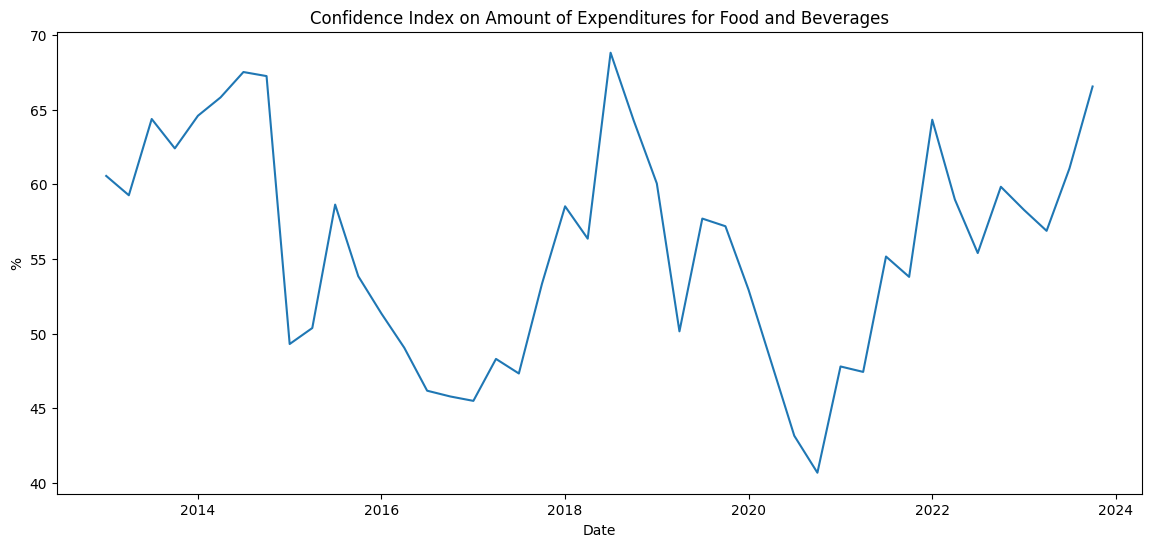

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(df3['Date'], df3['Confidence Index on Amount of Expenditures (PH)'])
plt.title('Confidence Index on Amount of Expenditures for Food and Beverages')
plt.ylabel('%')
plt.xlabel('Date')
plt.show()

## 4. SMC Financial Report Data

Selected annual financial figures are loaded as an additional company-level reference, including revenue, cost of goods sold, selling and administrative expenses, net income, and segment sales where available.


In [3]:
smc = pd.read_csv('SMC Financial Reports.csv')
smc

,Year,Revenue,COGS,Selling and Administrative Expenses,Net Income,Food Sales,Beer & NAB Sales,Additional Paid-in Stock
0,2013,"9,972,930,000.00","79,547,532,000.00","14,715,401,000.00","4,083,835,000.00",NaN,NaN,NaN
1,2014,"102,999,401,000.00","82,514,595,000.00","14,021,962,000.00","3,843,475,000.00",NaN,NaN,NaN
2,2015,"106,860,238,000.00","84,109,526,000.00","15,106,720,000.00","4,752,032,000.00",NaN,NaN,NaN
3,2016,"227,279,000,000.00","152,108,000,000.00","38,128,000,000.00","24,002,000,000.00","111,586,000,000.00","97,160,000,000.00",NaN
4,2017,"251,589,000,000.00","168,460,000,000.00","40,728,000,000.00","28,226,000,000.00","117,449,000,000.00","113,255,000,000.00",NaN
5,2018,"286,378,000,000.00","194,236,000,000.00","46,192,000,000.00","30,533,000,000.00","132,299,000,000.00","129,249,000,000.00",NaN
6,2019,"310,785,000,000.00","212,030,000,000.00","50,974,000,000.00","32,279,000,000.00","139,459,000,000.00","142,272,000,000.00",NaN
7,2020,"279,290,000,000.00","200,239,000,000.00","45,639,000,000.00","31,401,000,000.00","135,170,000,000.00","107,928,000,000.00",NaN
8,2021,"309,778,000,000.00","219,306,000,000.00","46,777,000,000.00","31,417,000,000.00","150,970,000,000.00","116,286,000,000.00",NaN
9,2022,"358,853,000,000.00","261,480,000,000.00","48,662,000,000.00","34,665,000,000.00","175,288,000,000.00","136,235,000,000.00",NaN


## 5. Key Takeaways and Limitations

- First-order differencing produced series that passed the ADF stationarity test at the 5% level in the original run.
- ARIMA model selection produced different optimal specifications for each commodity series, reflecting differences in their historical time-series behavior.
- The analysis supplements price forecasting with consumer indicators and financial report data to provide broader market context.
- The forecasts should be treated as **exploratory time-series estimates**, not production forecasts. The analysis relies on historical patterns, simple missing-value treatment, and univariate ARIMA specifications.
- Because the original CSV files are no longer included, this portfolio version is preserved as a record of the original analysis rather than a fully reproducible package.
